In [ ]:
import numpy as np

def convert_to_numerical_binary_vectors(x: np.ndarray, N: int) -> np.ndarray:
    """
    Converte ogni coppia di interi in un array NumPy in un singolo vettore
    numerico di bit (0 e 1), adattandosi dinamicamente a N.
    """
    num_bits = int(N / 2)
    final_vectors = []

    # Crea la stringa di formattazione dinamicamente
    format_spec = f'{{:0{num_bits}b}}'

    for row in x:
        # Applica la formattazione per ogni numero
        bin_str_1 = format_spec.format(row[0])
        bin_str_2 = format_spec.format(row[1])
        concatenated_string = bin_str_1 + bin_str_2

        numerical_vector = [int(bit) for bit in concatenated_string]
        final_vectors.append(numerical_vector)

    bin_var = np.array(final_vectors, dtype=np.int8)
    ising_var = 2 * bin_var - 1

    return ising_var

def define_perfect_perceptron(N = 20):
    """
    Inizializzazione dell'array di pesi del Perceptron perfetto.
    """
    positive_part = 2 ** np.arange((N/2) -1, -1, -1)
    return np.concatenate((positive_part, -positive_part))

class Perceptron:
  def __init__(self, N=20, J=None, seed=None):
    self.seed = seed
    self.rng = np.random.default_rng(seed)
    self.N = N

    if J is None:
      self.J = self.rng.normal(0, 1, self.N)
    else:
      self.J = J

    self.evolution_J = []

  def _sign_activation(self, x):
    return np.sign(x)

  def predict(self, x_binary):
    """Esegue predizioni usando i coefficienti del modello fittato."""
    return self._sign_activation(np.dot(x_binary, self.J))

  def evaluate(self, x_binary, y):
    """Calcola l'errore medio di classificazione."""
    y_pred = self.predict(x_binary)
    y = np.atleast_1d(y)
    return np.mean(y_pred != y)

  def fit(self, x_binary, y, epochs=5000):
    """
    Fitta il modello sui dati con la logica di training corretta.
    """
    # Salva lo stato iniziale
    self.evolution_J.append(self.J.copy())

    for epoch in range(epochs):
        updates_in_epoch = 0

        combined_data = list(zip(x_binary, y))
        self.rng.shuffle(combined_data)

        for xi, yi in combined_data:
            yi_pred = self.predict(xi.reshape(1, -1))

            if yi_pred[0] != yi:
                updates_in_epoch += 1

                self.J += (yi * xi) / np.sqrt(self.N)

        self.evolution_J.append(self.J.copy())

        if updates_in_epoch == 0 and epoch > 0:
            print(f"Convergenza raggiunta all'epoca {epoch + 1}.")
            return self.J.copy()

    print(f"Training terminato dopo {epochs} epoche (max epoche raggiunto).")
    return self.J.copy()


  def fit_noise(self, x_binary, y, sigma2=50, epochs=5000):
    """
    Fitta il modello sui dati di training con l'aggiunta di rumore gaussiano.
    """
    # Salva lo stato iniziale
    self.evolution_J.append(self.J.copy())

    for epoch in range(epochs):
        updates_in_epoch = 0

        combined_data = list(zip(x_binary, y))
        self.rng.shuffle(combined_data)

        for xi, yi in combined_data:
            yi_pred = self.predict(xi.reshape(1, -1))

            if yi_pred[0] != yi:
                updates_in_epoch += 1
                r = self.rng.normal(0, np.sqrt(sigma2))
                self.J += (1 + r)*(yi * xi) / np.sqrt(self.N)

        self.evolution_J.append(self.J.copy())

        if updates_in_epoch == 0 and epoch > 0:
            # print(f"Convergenza del training con noise (mu=0, sigma^2={sigma2}) raggiunta all'epoca {epoch + 1}.")
            return self.J.copy()

    print(f"Training con noise terminato dopo {epochs} epoche (max epoche raggiunto).")
    return self.J.copy()

class SyntheticDataGenerator:
  def __init__(self, seed=None, N=20):
    self.seed = seed
    self.rng = np.random.default_rng(seed)
    self.N = N
    self.teacher = Perceptron(N=N, J=define_perfect_perceptron(N))

  def generate_data(self, P):
    """
    Genera un set completo di dati (x, y) di P campioni,
    assicurandosi che nessuna coppia (a, b) abbia a == b.
    """
    x = self.rng.integers(2**(self.N/2), size=(P, 2))

    duplicate_mask = (x[:, 0] == x[:, 1])
    num_duplicates = np.sum(duplicate_mask)

    while num_duplicates > 0:
      new_samples = self.rng.integers(2**(self.N/2), size=(num_duplicates, 2))

      x[duplicate_mask] = new_samples

      duplicate_mask = (x[:, 0] == x[:, 1])
      num_duplicates = np.sum(duplicate_mask)

    y = self.teacher.predict(convert_to_numerical_binary_vectors(x, self.N))

    return convert_to_numerical_binary_vectors(x, self.N), y


In [ ]:
import matplotlib.pyplot as plt
import re
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from scipy.optimize import root_scalar

def f1(eps, alpha):
  return 1 - alpha * np.tan(np.pi * eps) / np.pi

def f2(eps, alpha):
  return np.arctan((np.pi*(1-eps)) / alpha) / (np.pi)

def evolution_vs_a_procedure(alpha, eps_0, a_values, f, max_epochs=200):
    """
    Calcola l'evoluzione della procedura iterativa per un alpha fisso
    e un array di diversi valori di smorzamento 'a'.
    Restituisce una matrice (epoche, numero di 'a') con l'intera storia.
    """
    a_values = np.asarray(a_values)
    num_a_values = len(a_values)
    old_eps = np.full(num_a_values, float(eps_0))
    results_history = np.zeros((max_epochs, num_a_values))

    for epoch in range(max_epochs):
        f_val = f(old_eps, alpha)
        new_eps = (1 - a_values) * old_eps + a_values * f_val
        results_history[epoch, :] = new_eps
        old_eps = new_eps

    return results_history

def vectorized_iterative_procedure(alphas, eps_0, a, f, max_epochs=2000, tol=1e-8):
    """
    Calcola l'evoluzione della procedura iterativa per un array di valori alpha.
    Restituisce una matrice (epoche, numero di alpha) con l'intera storia.
    Si ferma prima se la convergenza viene raggiunta.
    """
    alphas = np.asarray(alphas)
    num_alphas = len(alphas)
    old_eps = np.full(num_alphas, float(eps_0))
    results_history = np.zeros((max_epochs, num_alphas))

    for epoch in range(max_epochs):
        new_eps = (1 - a) * old_eps + a * f(old_eps, alphas)
        results_history[epoch, :] = new_eps

        # Criterio di arresto per efficienza
        if np.all(np.abs(new_eps - old_eps) < tol):
            print(f"Convergenza del punto fisso raggiunta all'epoca {epoch + 1}.")
            # Riempi il resto della storia con l'ultimo valore per un plot corretto
            results_history[epoch+1:, :] = new_eps
            return results_history[:epoch+1] # Restituisce solo le epoche calcolate

        old_eps = new_eps

    print(f"Attenzione: Max epoche ({max_epochs}) raggiunto.")
    return results_history

def compare_dynamics(f1, f2, alpha, eps_0, a_values, max_epochs):
    """
    Esegue la simulazione per due funzioni f1 e f2 e plotta i risultati
    in due subplot affiancati.
    """
    print("--- Inizio Calcolo Dinamiche ---")

    # 1. Esegui la procedura per la prima funzione
    print(f"Calcolo per f1 con alpha={alpha}, eps_0={eps_0}...")
    evolution1 = evolution_vs_a_procedure(alpha, eps_0, a_values, f1, max_epochs)

    # 2. Esegui la procedura per la seconda funzione
    print(f"Calcolo per f2 con alpha={alpha}, eps_0={eps_0}...")
    evolution2 = evolution_vs_a_procedure(alpha, eps_0, a_values, f2, max_epochs)

    print("--- Calcolo Completato. Inizio Plotting. ---")

    # 3. Prepara il grafico con due subplot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7)) # 1 riga, 2 colonne

    epoch_axis = np.arange(max_epochs)
    colors = ['royalblue', 'darkorange', 'green']

    # --- Subplot 1: Dinamica per f1 ---

    # Trova il punto fisso per riferimento
    try:
        pf1 = root_scalar(lambda eps: eps - f1(eps, alpha), x0=eps_0, bracket=[0.01, 0.499]).root
        ax1.axhline(y=pf1, color='black', linestyle='--', label=f'Punto fisso ≈ {pf1:.3f}')
    except ValueError:
        print("Nessun punto fisso trovato per f1.")

    for i, a_val in enumerate(a_values):
        trajectory = evolution1[:, i]
        # Concatena il punto iniziale (eps_0) con la traiettoria calcolata
        full_trajectory = np.concatenate(([eps_0], trajectory))
        # L'asse x ora deve avere un punto in più all'inizio (epoca 0)
        full_epoch_axis = np.concatenate(([0], epoch_axis))

        ax1.plot(
            full_epoch_axis,
            full_trajectory,
            label=f'a = {a_val}',
            color=colors[i % len(colors)],
            alpha=0.8,
            linewidth=2.5
        )

    ax1.set_title(r'Dinamica per Funzione $f_1$', fontsize=16)
    ax1.set_xlabel('Epoca (i)', fontsize=14)
    ax1.set_ylabel(r'Valore di $\epsilon_i$', fontsize=14)
    ax1.set_ylim(bottom=0, top=0.55)
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.7)

    # --- Subplot 2: Dinamica per f2 ---

    # Trova il punto fisso per riferimento
    try:
        pf2 = root_scalar(lambda eps: eps - f2(eps, alpha), x0=eps_0).root
        ax2.axhline(y=pf2, color='black', linestyle='--', label=f'Punto fisso ≈ {pf2:.3f}')
    except ValueError:
        print("Nessun punto fisso trovato per f2.")

    for i, a_val in enumerate(a_values):
        trajectory = evolution2[:, i]
        full_trajectory = np.concatenate(([eps_0], trajectory))
        full_epoch_axis = np.concatenate(([0], epoch_axis)) # Puoi definire l'asse una volta sola

        ax2.plot(
            full_epoch_axis,
            full_trajectory,
            label=f'a = {a_val}',
            color=colors[i % len(colors)],
            alpha=0.8,
            linewidth=2.5
        )

    ax2.set_title(r'Dinamica per Funzione $f_2$', fontsize=16)
    ax2.set_xlabel('Epoca (i)', fontsize=14)
    # Rimuoviamo l'etichetta y per pulizia, dato che è la stessa del primo plot
    ax2.tick_params(axis='y', labelleft=False)
    ax2.set_ylim(bottom=0, top=0.55)
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.7)

    # Aggiungi un titolo generale
    fig.suptitle(f'Confronto Dinamiche di Convergenza per $\\alpha={alpha}$ e $\\epsilon_0={eps_0}$', fontsize=20, y=1.02)

    plt.tight_layout()
    plt.show()

def plot_results():
    """
    Genera il grafico che confronta la curva parametrica teorica
    con i punti fissi calcolati iterativamente.
    """

    # --- 1. Calcolo della Curva Parametrica Teorica (Annealed) ---
    def parametric_alphas(eps):
        # Stabilità numerica ai limiti
        eps = np.asarray(eps)
        # Clona per non modificare l'array originale
        safe_eps = np.copy(eps)

        # Evita la divisione per zero in tan(pi*eps) agli estremi
        safe_eps[safe_eps < 1e-9] = 1e-9
        safe_eps[safe_eps > 0.5 - 1e-9] = 0.5 - 1e-9

        return np.pi * (1 - safe_eps) / np.tan(np.pi * safe_eps)

    # Genera i valori per la curva liscia
    eps_values_parametric = np.linspace(1e-9, 0.5, 500)
    alpha_values_parametric = parametric_alphas(eps_values_parametric)

    # --- 2. Calcolo dei Punti Fissi tramite Iterazione ---
    # Definiamo i parametri per la dinamica
    A_FIXED = 0.9
    EPS_ZERO_FIXED = 0.5 # Partiamo dal guessing casuale
    MAX_EPOCHS_FIXED = 5000 # Diamo tempo sufficiente per convergere

    # Creiamo un array di alpha per cui calcolare il punto fisso
    alphas_for_fixed_point = np.linspace(0.01, 10, 100) # 25 punti tra 0.1 e 10

    print("Calcolo dei punti fissi tramite iterazione...")
    # Calcoliamo l'evoluzione per tutti gli alpha in una sola chiamata
    evolution_matrix = vectorized_iterative_procedure(
        alphas_for_fixed_point,
        EPS_ZERO_FIXED,
        A_FIXED,
        f2,
        max_epochs=MAX_EPOCHS_FIXED
    )

    # Estraiamo l'ultimo valore di epsilon per ogni alpha (il punto fisso raggiunto)
    fixed_point_eps = evolution_matrix[-1, :]
    print("Calcolo completato.")

    # --- 3. Creazione del Grafico ---
    fig, ax = plt.subplots(figsize=(14, 9))

    # Plotta la curva parametrica teorica
    ax.plot(alpha_values_parametric, eps_values_parametric, color='gray', linestyle='--', linewidth=2.5, label='Teoria Annealed (Parametrica)')

    # Plotta i punti fissi trovati iterativamente
    ax.plot(
        alphas_for_fixed_point,
        fixed_point_eps,
        'o', # Stile: cerchi
        markersize=8,
        color='red',
        label=f'Punti Fissi da Dinamica ($f_2$, a={A_FIXED})'
    )

    # --- Personalizzazione del Grafico ---
    title_fontsize = 20
    label_fontsize = 18
    legend_fontsize = 16
    tick_fontsize = 14

    ax.set_title(r"Confronto tra Teoria e Punti Fissi della Dinamica", fontsize=title_fontsize, pad=20)
    ax.set_xlabel(r"$\alpha = p/N$", fontsize=label_fontsize)
    ax.set_ylabel(r"$\epsilon$ (Errore di Generalizzazione)", fontsize=label_fontsize)
    ax.legend(fontsize=legend_fontsize)
    ax.grid(True, which='both', linestyle='--', alpha=0.6)

    ax.set_xlim(left=0, right=10)
    ax.set_ylim(bottom=-0.02, top=0.55)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

    plt.tight_layout()
    plt.show()

def solve_annealed_epsilon(P, N):
    """
    Risolve l'equazione trascendentale per trovare epsilon* dato alpha.
    L'equazione è: pi * (1 - eps) * cot(pi * eps) - alpha = 0
    """
    if P == 0:
        return 0.5 # Caso di guessing casuale

    # Definiamo la funzione di cui trovare la radice
    def equation(eps):
        # Stabilità numerica: cot(x) = 1/tan(x)
        if eps == 0 or eps == 0.5: # Evita la divisione per zero o il valore esatto
             return np.pi * (1 - 2/N) * (1 - eps) / np.tan(np.pi * eps) - P/N
        return np.pi * (1 - eps) * (1 - 2/N) * np.cos(np.pi * eps) / np.sin(np.pi * eps) - P/N

    # Troviamo la radice nell'intervallo fisicamente sensato (0, 0.5)
    # Usiamo un bracket stretto per evitare le singolarità del cotangente
    sol = root_scalar(equation, bracket=[1e-9, 0.5 - 1e-9], method='brentq')
    return sol.root

def calculate_annealed_theory(N, p_values):
    """
    Calcola la curva teorica del valor medio di epsilon usando il metodo di Laplace.
    """
    print(f"Inizio calcolo teorico (Annealed) per N={N}...")
    theoretical_eps = [solve_annealed_epsilon(p_value, N) for p_value in p_values]
    print(f"Calcolo teorico per N={N} completato.")
    return theoretical_eps


class Experiment:
  def __init__(self, name):
    """
    Inizializza l'esperimento.
    """
    self.name = name
    self.results = {} # Un dizionario per conservare i risultati

  # def _solve_annealed_epsilon(self, P, N):
  #   """
  #   Metodo helper per risolvere l'equazione trascendentale (Annealed/Laplace).
  #   """
  #   if P == 0:
  #       return 0.5

  #   def equation(eps):
  #       # Stabilità numerica: cot(x) = 1/tan(x)
  #       if eps == 0 or eps == 0.5: # Evita la divisione per zero o il valore esatto
  #            return np.pi * (1 - 2/N) * (1 - eps) / np.tan(np.pi * eps) - P/N
  #       return np.pi * (1 - eps) * (1 - 2/N) * np.cos(np.pi * eps) / np.sin(np.pi * eps) - P/N

  #   sol = root_scalar(equation, bracket=[1e-9, 0.5 - 1e-9], method='brentq')
  #   return sol.root

  # def _calculate_annealed_theory(self, N, p_values):
  #   """
  #   Metodo helper per calcolare la curva teorica completa.
  #   """
  #   print(f"Inizio calcolo teorico (Annealed/Laplace) per N={N}...")
  #   theoretical_eps = [self._solve_annealed_epsilon(p_value, N) for p_value in p_values]
  #   print(f"Calcolo teorico per N={N} completato.")
  #   return theoretical_eps

  def run(self):
    """Esegue l'esperimento: genera dati, fitta il modello e valuta."""
    print(f"--- Esecuzione Esperimento: {self.name} ---")

    # 0. Definizione dei parametri globali
    test_size = 1000
    runs_num = 1000
    sigma2 = 50

    # 1. Definizione dei parametri della prima simulazione
    train_sizes_20 = [1, 10, 20, 50, 100, 150, 200]
    N_20 = 20

    # 2. Esecuzione della prima simulazione con N=20
    error_means_20, error_stds_20 = self.simulation(train_sizes_20, test_size, runs_num, sigma2, N_20)

    # 3. Definizione dei parametri della seconda simulazione
    train_sizes_40 = [1, 2, 20, 40, 100, 200, 300]
    N_40 = 40

    # 4. Esecuzione della seconda simulazione con N=40
    error_means_40, error_stds_40 = self.simulation(train_sizes_40, test_size, runs_num, sigma2, N_40)

    # 6. Salvataggio Risultati ---
    self.results = {
        'error_means_20': error_means_20,
        'error_stds_20': error_stds_20,
        'train_sizes_20': train_sizes_20,
        'error_means_40': error_means_40,
        'error_stds_40': error_stds_40,
        'train_sizes_40': train_sizes_40
    }

    print("------------------------------------------\n")

  def simulation(self, train_sizes, test_size, runs_num, sigma2, N, seed=None):
    """
    Esegue la simulazione per i diversi valori di P.
    """
    print(f"Inizio simulazione con N = {N}:")
    if seed is None:
        data_generator = SyntheticDataGenerator(N=N)
    else:
      data_generator = SyntheticDataGenerator(seed=seed, N=N)

    x_val, y_val = data_generator.generate_data(P=test_size)

    errors_results = np.zeros((len(train_sizes), runs_num))

    for i, P in enumerate(train_sizes):
      for run in range(runs_num):
        if run % 100 == 0:
          print(f"Run {run+1}/{runs_num}, P = {P}, N = {N}")
        student_perceptron = Perceptron(N=N)
        x_train, y_train = data_generator.generate_data(P=P)
        student_perceptron.fit_noise(x_train, y_train, sigma2=sigma2)

        errors_results[i, run] = student_perceptron.evaluate(x_val, y_val)

    error_means = np.mean(errors_results, axis=1)
    error_stds = np.std(errors_results, axis=1)

    return error_means, error_stds

  def plot(self, results=None, save_figure=True):
    """
    Plotta l'andamento dell'errore di generalizzazione, confrontando i dati sperimentali
    con la teoria di Laplace (Annealed).
    """

    if results is None:
      if not self.results:
          raise RuntimeError("L'esperimento deve essere eseguito prima. Chiama il metodo .run()")
      res = self.results
    else:
      res = results

    p_values = np.arange(0, 501, 5)

    # Calcolo teorico basato su Laplace/Annealed
    theory_eps_20 = calculate_annealed_theory(N=20, p_values=p_values)
    theory_eps_40 = calculate_annealed_theory(N=40, p_values=p_values)
    # theory_eps_20 = self._calculate_annealed_theory(N=20, p_values=p_values)
    # theory_eps_40 = self._calculate_annealed_theory(N=40, p_values=p_values)

    # --- Impostazioni del Grafico ---
    title_fontsize = 20
    label_fontsize = 18
    legend_fontsize = 16
    tick_fontsize = 14

    fig1, ax1 = plt.subplots(figsize=(14, 9))

    # --- Plot Dati Sperimentali N=20 ---
    ax1.errorbar(
        res['train_sizes_20'], res['error_means_20'], yerr=res['error_stds_20'],
        label='Sperimentale N = 20', marker='o',
        capsize=5, color='royalblue', zorder=10 # zorder alto per stare sopra
    )

    # --- Plot Dati Sperimentali N=40 ---
    ax1.errorbar(
        res['train_sizes_40'], res['error_means_40'], yerr=res['error_stds_40'],
        label='Sperimentale N = 40', marker='s',
        capsize=5, color='red', zorder=10
    )

    # Plot Curva Teorica N=20
    ax1.plot(
        p_values, theory_eps_20,
        label='Teoria Laplace N = 20',
        color='skyblue', linestyle='--', linewidth=2.5
    )

    # Plot Curva Teorica N=40
    ax1.plot(
        p_values, theory_eps_40,
        label='Teoria Laplace N = 40',
        color='salmon', linestyle='--', linewidth=2.5
    )

    # --- Personalizzazione Grafico ---
    ax1.set_title("Errore di Generalizzazione: Confronto Sperimentale vs Teorico", fontsize=title_fontsize, pad=20)
    ax1.set_xlabel("p (Numero di esempi)", fontsize=label_fontsize)
    ax1.set_ylabel(r"$\langle \epsilon \rangle$ (Errore Medio di Generalizzazione)", fontsize=label_fontsize)
    ax1.legend(fontsize=legend_fontsize)
    ax1.grid(True, which='both', linestyle='--', alpha=0.6)

    ax1.set_xlim(left=0, right=500)
    ax1.set_ylim(bottom=-0.02, top=0.55)
    ax1.tick_params(axis='both', which='major', labelsize=tick_fontsize)

    fig2, ax2 = plt.subplots(figsize=(14, 9))

    # --- Plot Dati Sperimentali N=20 ---
    ax2.errorbar(
        res['train_sizes_20']/20, res['error_means_20'], yerr=res['error_stds_20'],
        label='Sperimentale N = 20', marker='o',
        capsize=5, color='royalblue', zorder=10 # zorder alto per stare sopra
    )

    # --- Plot Dati Sperimentali N=40 ---
    ax2.errorbar(
        res['train_sizes_40']/40, res['error_means_40'], yerr=res['error_stds_40'],
        label='Sperimentale N = 40', marker='s',
        capsize=5, color='red', zorder=10
    )

    # Plot Curva Teorica N=20
    ax2.plot(
        p_values/20, theory_eps_20,
        label='Teoria Laplace N = 20',
        color='skyblue', linestyle='--', linewidth=2.5
    )

    # Plot Curva Teorica N=40
    ax2.plot(
        p_values/40, theory_eps_40,
        label='Teoria Laplace N = 40',
        color='salmon', linestyle='--', linewidth=2.5
    )

    # --- Personalizzazione Grafico ---
    ax2.set_title(r"Errore di Generalizzazione: Confronto Sperimentale vs Teorico in funzione di $\alpha$", fontsize=title_fontsize, pad=20)
    ax2.set_xlabel(r"$\alpha$", fontsize=label_fontsize)
    ax2.set_ylabel(r"$\langle \epsilon \rangle$ (Errore Medio di Generalizzazione)", fontsize=label_fontsize)
    ax2.legend(fontsize=legend_fontsize)
    ax2.grid(True, which='both', linestyle='--', alpha=0.6)

    ax2.set_xlim(left=0, right=500)
    ax2.set_ylim(bottom=-0.02, top=0.55)
    ax2.tick_params(axis='both', which='major', labelsize=tick_fontsize)


    plt.tight_layout()

    if save_figure:
        filename_p = "learning_curves_exp_vs_theory_p.png"
        filename_alpha = "learning_curves_exp_vs_theory_alpha.png"
        print(f"\nSalvataggio della figure in: {filename_p} e {filename_alpha}")
        fig1.savefig(filename_p, dpi=300, bbox_inches='tight')
        fig2.savefig(filename_alpha, dpi=300, bbox_inches='tight')

    plt.show()

  def plot_advanced_comparison(self, results=None, save_figure=True):
    """
    Evoluzione del metodo plot().
    Plotta l'errore di generalizzazione in funzione di alpha, confrontando:
    1. Dati sperimentali per N=20 e N=40 con errore standard della media.
    2. Curva teorica Annealed (parametrica).
    3. Curva teorica ottenuta dalla convergenza della mappa iterativa con f2.
    """
    print("\n--- Esecuzione Plot Avanzato ---")
    if results is None:
        if not self.results:
            raise RuntimeError("L'esperimento deve essere eseguito prima. Chiama il metodo .run()")
        res = self.results
    else:
        res = results
    #   self.results = {
    #     'error_means_20': error_means_20,
    #     'error_stds_20': error_stds_20,
    #     'train_sizes_20': train_sizes_20,
    #     'error_means_40': error_means_40,
    #     'error_stds_40': error_stds_40,
    #     'train_sizes_40': train_sizes_40
    # }

    # --- 1. Preparazione Dati Sperimentali ---
    alpha_20 = np.array(res['train_sizes_20']) / 20
    error_mean_20 = res['error_means_20']
    # Calcolo dell'errore standard della media
    sem_20 = res['error_stds_20'] / np.sqrt(1000)

    alpha_40 = np.array(res['train_sizes_40']) / 40
    error_mean_40 = res['error_means_40']
    sem_40 = res['error_stds_40'] / np.sqrt(1000)

    # --- 2. Calcolo Curva Teoria Parametrica (Annealed) ---
    print("Calcolo curva teorica parametrica (Annealed)...")
    def parametric_alphas(eps):
        eps = np.asarray(eps)
        safe_eps = np.copy(eps)
        safe_eps[safe_eps < 1e-9] = 1e-9
        # Per la teoria Annealed pura, il limite è 0.5, non 0.5-1/N
        safe_eps[safe_eps >= 0.5] = 0.5 - 1e-9
        return np.pi * (1 - safe_eps) / np.tan(np.pi * safe_eps)

    eps_parametric = np.linspace(1e-9, 0.5, 500)
    alpha_parametric = parametric_alphas(eps_parametric)

    # --- 3. Calcolo Curva Teoria da Mappa Iterativa (f2) ---
    print("Calcolo curva teorica da mappa iterativa (f2)...")
    A_FIXED = 0.9
    EPS_ZERO_FIXED = 0.5
    MAX_EPOCHS_FIXED = 5000

    alphas_for_map = np.linspace(0.01, 15, 200) # Range più ampio per una curva liscia

    evolution_matrix = vectorized_iterative_procedure(
        alphas_for_map,
        EPS_ZERO_FIXED,
        A_FIXED,
        f2,
        max_epochs=MAX_EPOCHS_FIXED
    )
    # Estraiamo il punto fisso (ultimo valore) per ogni alpha
    eps_from_map = evolution_matrix[-1, :]
    print("Calcoli teorici completati.")

    # --- 4. Creazione del Grafico ---
    fig, ax = plt.subplots(figsize=(14, 9))

    # Plot Curva Teoria Parametrica
    ax.plot(alpha_parametric, eps_parametric, color='black', linestyle='--', linewidth=3,
            label='Teoria Annealed (Parametrica)')

    # Plot Curva Teoria da Mappa Iterativa
    ax.plot(alphas_for_map, eps_from_map, color='green', linestyle='-', linewidth=2.5,
            label=f'Teoria da Mappa Iterativa ($f_2$, a={A_FIXED})')

    # Plot Dati Sperimentali N=20
    ax.errorbar(
        alpha_20, error_mean_20, yerr=sem_20,
        label='Sperimentale N = 20', marker='o', markersize=8,
        linestyle='-', capsize=5, color='royalblue', zorder=10
    )

    # Plot Dati Sperimentali N=40
    ax.errorbar(
        alpha_40, error_mean_40, yerr=sem_40,
        label='Sperimentale N = 40', marker='s', markersize=8,
        linestyle='-', capsize=5, color='red', zorder=10
    )

    # --- Personalizzazione Grafico ---
    title_fontsize = 20
    label_fontsize = 18
    legend_fontsize = 16
    tick_fontsize = 14

    ax.set_title(r"Confronto Avanzato: Dati Sperimentali vs Teorie", fontsize=title_fontsize, pad=20)
    ax.set_xlabel(r"$\alpha = p/N$", fontsize=label_fontsize)
    ax.set_ylabel(r"$\langle \epsilon \rangle$ (Errore Medio di Generalizzazione)", fontsize=label_fontsize)
    ax.legend(fontsize=legend_fontsize)
    ax.grid(True, which='both', linestyle='--', alpha=0.6)

    # Adattiamo i limiti del grafico in base ai dati
    max_alpha_exp = max(np.max(alpha_20), np.max(alpha_40))
    ax.set_xlim(left=-0.2, right=max_alpha_exp + 1)
    ax.set_ylim(bottom=-0.02, top=0.55)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

    plt.tight_layout()

    if save_figure:
        filename = "advanced_comparison_plot.png"
        print(f"\nSalvataggio della figure in: {filename}")
        fig.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

Calcolo dei punti fissi tramite iterazione...
Convergenza del punto fisso raggiunta all'epoca 9.
Calcolo completato.


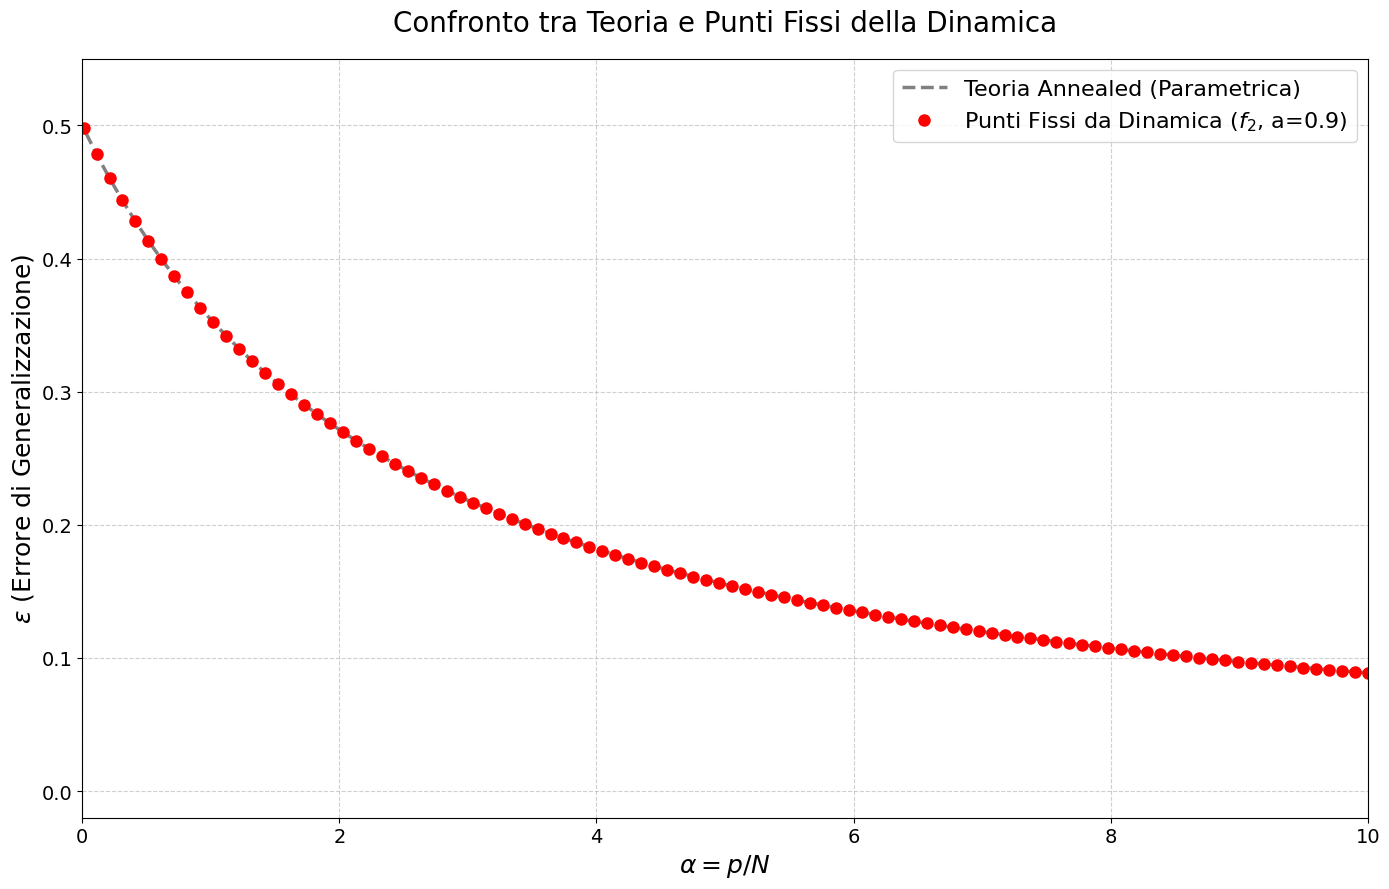

--- Inizio Calcolo Dinamiche ---
Calcolo per f1 con alpha=5, eps_0=0.25...
Calcolo per f2 con alpha=5, eps_0=0.25...
--- Calcolo Completato. Inizio Plotting. ---


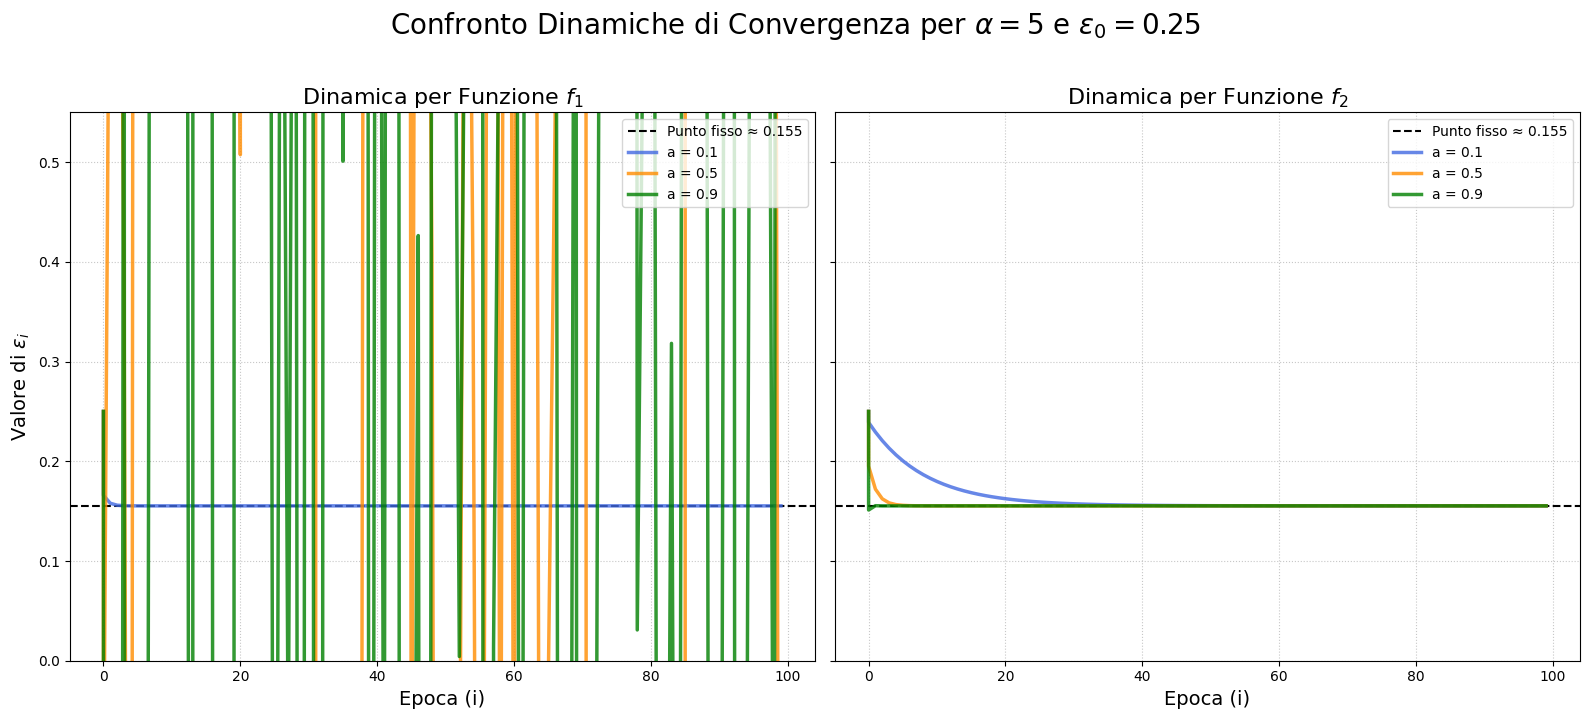

In [ ]:
plot_results()

eps_0 = 0.25
alpha = 5
a_values = np.array([0.1, 0.5, 0.9])
compare_dynamics(f1, f2, alpha, eps_0, a_values, max_epochs=100)


In [ ]:
experiment = Experiment("Confronto Training N=20 e N=40")
experiment.run()
results = experiment.results
print(results)

--- Esecuzione Esperimento: Confronto Training N=20 e N=40 ---
Inizio simulazione con N = 20:
Run 1/1000, P = 1, N = 20
Run 101/1000, P = 1, N = 20
Run 201/1000, P = 1, N = 20
Run 301/1000, P = 1, N = 20
Run 401/1000, P = 1, N = 20
Run 501/1000, P = 1, N = 20
Run 601/1000, P = 1, N = 20
Run 701/1000, P = 1, N = 20
Run 801/1000, P = 1, N = 20
Run 901/1000, P = 1, N = 20
Run 1/1000, P = 10, N = 20
Run 101/1000, P = 10, N = 20
Run 201/1000, P = 10, N = 20
Run 301/1000, P = 10, N = 20
Run 401/1000, P = 10, N = 20
Run 501/1000, P = 10, N = 20
Run 601/1000, P = 10, N = 20
Run 701/1000, P = 10, N = 20
Run 801/1000, P = 10, N = 20
Run 901/1000, P = 10, N = 20
Run 1/1000, P = 20, N = 20
Run 101/1000, P = 20, N = 20
Run 201/1000, P = 20, N = 20
Run 301/1000, P = 20, N = 20
Run 401/1000, P = 20, N = 20
Run 501/1000, P = 20, N = 20
Run 601/1000, P = 20, N = 20
Run 701/1000, P = 20, N = 20
Run 801/1000, P = 20, N = 20
Run 901/1000, P = 20, N = 20
Run 1/1000, P = 50, N = 20
Run 101/1000, P = 50, N =


--- Esecuzione Plot Avanzato ---
Calcolo curva teorica parametrica (Annealed)...
Calcolo curva teorica da mappa iterativa (f2)...
Convergenza del punto fisso raggiunta all'epoca 9.
Calcoli teorici completati.

Salvataggio della figure in: advanced_comparison_plot.png


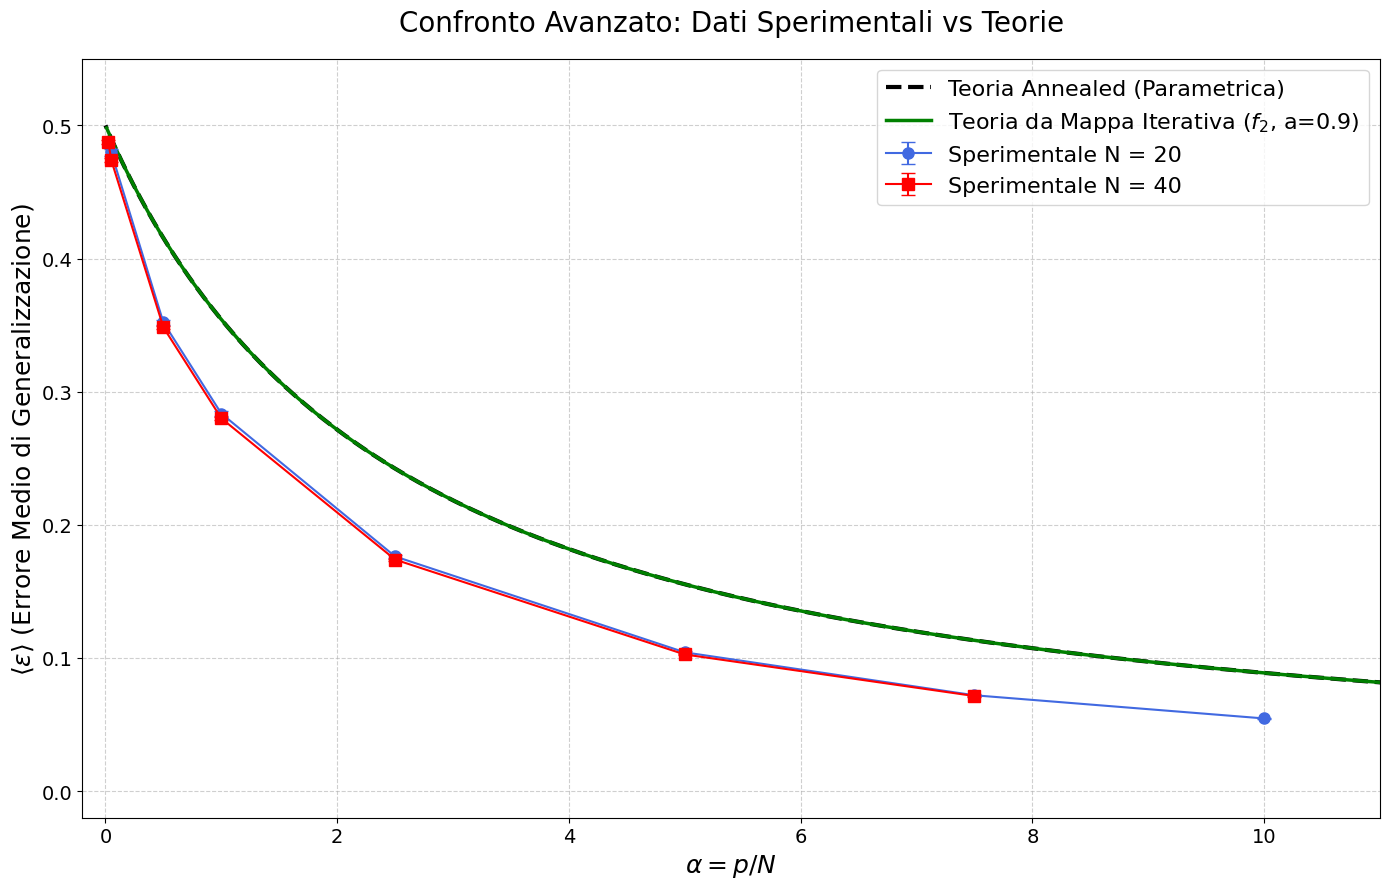

In [ ]:
Experiment.plot_advanced_comparison(experiment, results)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import root_scalar

# --- Funzioni per l'Integrazione Numerica Esatta (il tuo codice, rinominato per chiarezza) ---

def integrand_prob(epsilon, N, p):
    """
    Calcola il valore della funzione di probabilità (non normalizzata) P(epsilon).
    P(epsilon) ~ (sin(pi*epsilon))^(N-2) * (1-epsilon)^p
    """
    if epsilon == 0.0 or epsilon == 1.0:
        return 0.0 # sin(0) e sin(pi) sono 0

    sin_term = np.sin(epsilon * np.pi)
    term1 = np.power(sin_term, N - 2)
    term2 = np.power(1 - epsilon, p)

    return term1 * term2

def integrand_for_mean(epsilon, N, p):
    """Calcola epsilon * P(epsilon) per il numeratore del valor medio."""
    return epsilon * integrand_prob(epsilon, N, p)

def calculate_numerical_mean_epsilon(N, p_values):
    """
    Calcola il valor medio "esatto" di epsilon per un dato N al variare di P,
    integrando numericamente.
    """
    mean_values = []
    print(f"Inizio calcolo numerico esatto per N={N}...")

    for i, p in enumerate(p_values):
        if (i > 0 and i % 50 == 0) or i == len(p_values) - 1:
            print(f"  N={N}, completato P={p} ({i}/{len(p_values)-1})")

        # 1. Calcola l'integrale di normalizzazione (denominatore)
        norm_integral, _ = quad(integrand_prob, 0, 1, args=(N, p), limit=100)

        # 2. Calcola l'integrale per il numeratore
        mean_integral, _ = quad(integrand_for_mean, 0, 1, args=(N, p), limit=100)

        # 3. Calcola il rapporto (il valor medio)
        if norm_integral > 1e-300: # Usiamo una tolleranza molto bassa
            mean_epsilon = mean_integral / norm_integral
            mean_values.append(mean_epsilon)
        else:
            # Se la normalizzazione è zero, il valor medio è 0 (tutto collassa a epsilon=0)
            mean_values.append(0)

    print(f"Calcolo numerico per N={N} completato.")
    return mean_values

# --- Funzione per la Soluzione Teorica (Metodo di Laplace / Annealed) ---

# --- Parametri della Simulazione ---
p_values = np.arange(0, 501, 5) # Calcoliamo ogni 5 punti per velocizzare

# --- Esecuzione del Calcolo ---
# Calcolo numerico esatto
mean_eps_N20_num = calculate_numerical_mean_epsilon(N=20, p_values=p_values)
mean_eps_N40_num = calculate_numerical_mean_epsilon(N=40, p_values=p_values)

# Calcolo teorico basato su Laplace/Annealed
mean_eps_N20_th = calculate_annealed_theory(N=20, p_values=p_values)
mean_eps_N40_th = calculate_annealed_theory(N=40, p_values=p_values)

# --- Creazione del Grafico 2D ---
fig, ax = plt.subplots(figsize=(14, 9))

# Plotta le curve per N=20
ax.plot(p_values, mean_eps_N20_num, label='N = 20 (Integrazione Numerica)', color='royalblue', linewidth=3)
ax.plot(p_values, mean_eps_N20_th, label='N = 20 (Laplace)', color='skyblue', linestyle='--', linewidth=2)

# Plotta le curve per N=40
ax.plot(p_values, mean_eps_N40_num, label='N = 40 (Integrazione Numerica)', color='red', linewidth=3)
ax.plot(p_values, mean_eps_N40_th, label='N = 40 (Laplace)', color='salmon', linestyle='--', linewidth=2)

# Aggiungi etichette e titolo
ax.set_title(r'Confronto tra Calcolo Esatto e Approssimazione di Laplace ($\langle \epsilon \rangle$ vs P)', fontsize=20, pad=20)
ax.set_xlabel('p (Numero di esempi)', fontsize=16)
ax.set_ylabel(r'$\langle \epsilon \rangle$ (Errore di Generalizzazione Medio)', fontsize=16)
ax.legend(fontsize=14, loc='upper right')
ax.tick_params(axis='both', which='major', labelsize=12)

# Imposta i limiti
ax.set_ylim(-0.02, 0.52)
ax.set_xlim(0, max(p_values))

ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()